In [ ]:
 # First Machine Learning Project

# Supervised Machine Learning -- Regression

# Regression is a supervised machine learning technique which is used to predict
# continuous values. The ultimate goal of the regression algorithm is to
# plot a best-fit line or a curve between the data.

# Regression analysis is a statistical method to model the relationship between
# a dependent (target) and independent (predictor) variables with one or more
# independent variables. More specifically, Regression analysis helps us
# to understand how the value of the dependent variable is changing corresponding to
# an independent variable.
# It predicts continuous/real values such as temperature, age, salary, price, etc.

# Example: Suppose there is a marketing company A, who does various advertisement
# every year and get sales on that. The below list shows the advertisement
# made by the company in the last 5 years and the corresponding sales:

#    Advertisement         Sales
#       $90                 $1000
#       $120                $1300
#       $150                $1800
#       $100                $1200
#       $170                 ??

# Now, the company wants to do the advertisement of $170 in the year 2026 and wants to know the
# prediction about the sales for this year.
# So to solve such type of prediction problems in machine learning, we need regression analysis.

'''
In Regression, we plot a graph between the variables which best fits the given datapoints,
using this plot, the machine learning model can make predictions about the data.
In simple words, "Regression shows a line or curve that passes through all the datapoints on
target-predictor graph in such a way that the vertical distance between the datapoints and the
regression line is minimum." The distance between datapoints and line tells whether a
model has captured a strong relationship or not.
'''

# Terms Used
# The variable that we are trying to explain or predict is called the
# response variable. It is also sometimes called the dependent variable
# because it depends on another variable.

# The variable that is used to explain or predict the response variable is called
# the explanatory variable. It is also sometimes called the independent
# variable because it is independent of the other variable.

# Simple Linear Regression
'''
Simple linear regression is used to estimate the relationship between two quantitative variables.
You can use simple linear regression when you want to know:
 a.) How strong the relationship is between two variables (e.g., the relationship between rainfall and soil erosion).
 b.) The value of the dependent variable at a certain value of the independent variable (e.g., the amount of soil erosion at a certain level of rainfall).

Regression models describe the relationship between variables by fitting a
line to the observed data.
Linear regression models use a straight line, while logistic and nonlinear regression models use a curved line.
Regression allows you to estimate how a dependent variable changes as the independent variable(s) change.

Simple linear regression example

You are a social researcher interested in the relationship between income and happiness.
You survey 500 people whose incomes range from 15k to 75k and ask them to rank their happiness on a scale from 1 to 10.
Your independent variable (income) and dependent variable (happiness) are both quantitative, so you can do a regression
analysis to see if there is a linear relationship between them.
'''

'''

Simple linear regression formula :
The formula for a simple linear regression is: y = B0 + B1X + E

y is the predicted value of the dependent variable (y) for any given value of the independent variable (x).
B0 is the intercept, the predicted value of y when the x is 0.
B1 is the regression coefficient – how much we expect y to change as x increases.
x is the independent variable ( the variable we expect is influencing y).
e is the error of the estimate, or how much variation there is in our estimate of the regression coefficient.
'''

# Dataset : https://raw.githubusercontent.com/yash240990/Python/master/Grade_Set_1.csv
print()

In [ ]:
# First Project : Predict Students Marks Based On Number Of Hours Studied

# import all the necessary libraries
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Step 1 : Data Gathering
data = pd.read_csv('https://raw.githubusercontent.com/yash240990/Python/master/Grade_Set_1.csv')
data

,Hours_Studied,Test_Grade,Status,Result
0,2,57,fail,D
1,3,66,fail,D
2,4,73,pass,C
3,5,76,pass,C
4,6,79,pass,C
5,7,81,pass,B
6,8,90,pass,B
7,9,96,pass,A
8,10,100,pass,A


In [ ]:
# step 2 : EDA
data.shape

(9, 4)

In [ ]:
data.columns

Index(['Hours_Studied', 'Test_Grade', 'Status', 'Result'], dtype='object')

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Hours_Studied  9 non-null      int64 
 1   Test_Grade     9 non-null      int64 
 2   Status         9 non-null      object
 3   Result         9 non-null      object
dtypes: int64(2), object(2)
memory usage: 420.0+ bytes


In [ ]:
# Step 3 : Data Preparation
# a.) check for missing and duplicate values
# b.) convert non-numerical features into numerical features
# c.) normalization
# d.) select independent and dependent variable

In [ ]:
# a.) check for mising and duplicate values
data.isnull().sum()

,0
Hours_Studied,0
Test_Grade,0
Status,0
Result,0


In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
# b.) convert non-numerical features into numerical features
import sklearn.preprocessing as pp
lb = pp.LabelBinarizer()

In [ ]:
# LabelBinarizer neg_label --> int, default=0  pos_label --> int,default=1
print(lb.fit_transform(['fail','pass']))
print(lb.fit_transform(['true','false']))
print(lb.fit_transform(['yes','no']))
print(lb.fit_transform(['positive','negative']))
print(lb.fit_transform(['success','fail']))


[[0]
 [1]]
[[1]
 [0]]
[[1]
 [0]]
[[1]
 [0]]
[[1]
 [0]]


In [ ]:
data.Status = lb.fit_transform(data.Status)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Hours_Studied  9 non-null      int64 
 1   Test_Grade     9 non-null      int64 
 2   Status         9 non-null      int64 
 3   Result         9 non-null      object
dtypes: int64(3), object(1)
memory usage: 420.0+ bytes


In [ ]:
# c.) normalization

vals = data.Test_Grade.values
print(vals)

normalized_values = pp.normalize([vals])
print(normalized_values)

min_max_sc = pp.MinMaxScaler()
normalized_values1 = min_max_sc.fit_transform([vals])
print(normalized_values1)

[ 57  66  73  76  79  81  90  96 100]
[[0.23500809 0.27211463 0.30097527 0.31334412 0.32571297 0.33395887
  0.37106541 0.3958031  0.4122949 ]]
[[0. 0. 0. 0. 0. 0. 0. 0. 0.]]


In [ ]:
# d.) select independent and dependent variable
# x is independent variable
# if X (idenpendent variable in 1D, must convert in 2D, because is a RULE)
x = data.Hours_Studied.values
x = x.reshape(9,1)
print(x)

[[ 2]
 [ 3]
 [ 4]
 [ 5]
 [ 6]
 [ 7]
 [ 8]
 [ 9]
 [10]]


In [ ]:
# y is dependent variable
y = data.Test_Grade.values
print(y)

[ 57  66  73  76  79  81  90  96 100]


In [ ]:
# Step 4 : Model Development
# Apply A Suitable ML Algo On Dataset

import sklearn.linear_model as lm
lin_reg = lm.LinearRegression()

In [ ]:
lin_reg.fit(x,y)

LinearRegression()

In [ ]:
# Step 5 : Evaluate Our Model Performance
data['predictedValues'] = lin_reg.predict(x)

In [ ]:
data[['Hours_Studied','Test_Grade','predictedValues']]

,Hours_Studied,Test_Grade,predictedValues
0,2,57,59.711111
1,3,66,64.727778
2,4,73,69.744444
3,5,76,74.761111
4,6,79,79.777778
5,7,81,84.794444
6,8,90,89.811111
7,9,96,94.827778
8,10,100,99.844444


In [ ]:
# WHAT IS INTERCEPT  c=21
# BASE VALUE OR STARTING VALUE
# THE PREDICTED VALUE OF Y WHEN X IS 0

# WHAT IS SLOPE m=13
# Change in he value of Y w.r.t X

In [ ]:
# R2 score --> coefficient of determination
# The R2 score indicates how well a model fits the observed data
# Is used to evaluate the performance of a linear regression model

# R2 score is 0.83
# This 0.83 means the model explains 83% of the variablity in the target variable

pred_values = lin_reg.predict(x)
pred_values

array([59.71111111, 64.72777778, 69.74444444, 74.76111111, 79.77777778,
       84.79444444, 89.81111111, 94.82777778, 99.84444444])

In [ ]:
from sklearn.metrics import r2_score
score = r2_score(y,pred_values)
print('Regression Score : ', score)

Regression Score :  0.9757431074095347


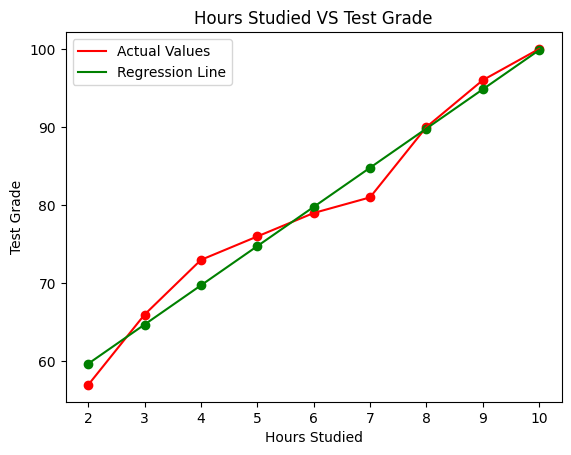

In [ ]:
# plot actual values
plt.plot(x,y,color='red',label='Actual Values')
plt.scatter(x,y,color='red')
# plot predicted values
plt.plot(x,pred_values,color='green',label='Regression Line')
plt.scatter(x,pred_values,color='green')
plt.title('Hours Studied VS Test Grade')
plt.xlabel('Hours Studied')
plt.ylabel('Test Grade')
plt.legend()
plt.show()

In [ ]:
# Step 6 : Final Predictions
hrs = float(input('Enter The Number Of Hours Studied : '))
marks = lin_reg.predict([[hrs]])
print(f'Student Who Will Study For {hrs} Hours Will Score {int(marks[0])} Marks.')

Enter The Number Of Hours Studied : 6.5
Student Who Will Study For 6.5 Hours Will Score 82 Marks.


In [ ]:
hrs = float(input('Enter The Number Of Hours Studied : '))
if hrs>0 and hrs<=10:
  marks = lin_reg.predict([[hrs]])
  print(f'Student Who Will Study For {hrs} Hours Will Score {int(marks[0])} Marks.')
else:
  print('Invalid Input')

Enter The Number Of Hours Studied : 8.5
Student Who Will Study For 8.5 Hours Will Score 92 Marks.
